<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Global%20Deforestation%20%26%20Afforestation%20(2000-2025).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Deforestation & Afforestation (2000-2025)



## Dataset Overview and Key Insights: Global Deforestation and Afforestation (2000-2025)

This dataset provides a comprehensive look at global forest dynamics between 2000 and 2025, focusing on deforestation and afforestation rates, forest cover, land area, and carbon stock across various countries. After initial data loading and inspection, which revealed no missing values except for the 'Primary_Driver_of_Change' column (which was subsequently dropped for most analyses to simplify the model), the dataset was prepared for in-depth statistical analysis and machine learning.

### Statistical Insights:

1.  **Net-Zero Trajectory (Wilcoxon Signed-Rank Test):** Analysis revealed a statistically significant ecological decline. Global afforestation efforts, on average, are mathematically failing to offset deforestation, indicating a net loss of forest area over the observed period. The average annual deforestation rate (0.6427) is higher than the average annual afforestation rate (0.5307), with a highly significant p-value.

2.  **Ecological Driver Impact (Kruskal-Wallis H-Test):** This test was intended to explore if the 'Primary_Driver_of_Change' influences the severity of deforestation. Due to the removal of the 'Primary_Driver_of_Change' column for subsequent machine learning feature engineering, this specific analysis could not be fully completed as originally designed to show driver-specific impacts.

3.  **Carbon Degradation Paradox (Spearman Rank Correlation):** A negative correlation was detected between the Net Forest Change Rate and Carbon Density per square kilometer. This suggests that as net forest growth decreases (i.e., deforestation outpaces afforestation), the remaining forests become denser in carbon per square kilometer. This might seem counterintuitive but can be explained by the fact that the most carbon-dense, old-growth forests are often the first to be cleared, or that the remaining, potentially younger, regenerating forests, while smaller in area, still contribute to the overall carbon density calculation relative to their reduced area.

### Time-Series Forecasting:

Time-series models (ARIMA and Exponential Smoothing) were employed to forecast global deforestation rates up to 2035. The ARIMA model, representing a "Business-as-Usual" scenario, projects a slight decrease in the deforestation rate by 2035, specifically a **3.81% DECREASE** from the 2025 baseline. This "hopeful" outlook suggests that, based on past trends, there might be a deceleration in the overall rate of forest loss.

### Machine Learning Predictions:

A Random Forest Regressor model emerged as the best performer, mathematically outperforming XGBoost with a remarkably high R-squared value of 0.9999 and a very low Mean Absolute Error (0.0004). This indicates the model is highly accurate in predicting annual deforestation rates. The feature importance analysis revealed that `'Deforestation_Z_Score'` (an engineered feature representing the deviation from the mean deforestation rate) was by far the most significant predictor. Other influential factors included `Forest_Cover_Pct`, `Sovereign_Risk_Encoded` (a Bayesian-encoded country-specific risk factor), `Carbon_Density_Per_km2`, and `Annual_Afforestation_Rate`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ashyou09/global-deforestation-and-afforestation-2000-2025

# Unziping the downloaded file
!unzip global-deforestation-and-afforestation-2000-2025.zip

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/ashyou09/global-deforestation-and-afforestation-2000-2025
License(s): apache-2.0
100% 106k/106k [00:00<00:00, 314kB/s]

Archive:  global-deforestation-and-afforestation-2000-2025.zip
  inflating: global_deforestation_2000_2025.csv  


# Data Inspection

In [11]:
df = pd.read_csv('global_deforestation_2000_2025.csv')
df.head(11)

,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes,Primary_Driver_of_Change
0,Brazil,2000,5468301,8515767,64.21,0.00,0.00,87197411954,Initial State
1,Brazil,2001,5439758,8515767,63.88,1.07,0.55,86742262748,NaN
2,Brazil,2002,5408757,8515767,63.51,1.43,0.86,86247929409,NaN
3,Brazil,2003,5326870,8515767,62.55,1.56,0.05,84942146407,NaN
4,Brazil,2004,5280984,8515767,62.01,0.94,0.08,84210458080,NaN
5,Brazil,2005,5260783,8515767,61.78,0.66,0.28,83888337477,NaN
6,Brazil,2006,5224830,8515767,61.35,1.05,0.37,83315028657,NaN
7,Brazil,2007,5226338,8515767,61.37,0.91,0.94,83339071402,NaN
8,Brazil,2008,5161193,8515767,60.61,1.42,0.17,82300277754,NaN
9,Brazil,2009,5141890,8515767,60.38,0.75,0.38,81992462967,NaN


In [12]:
df.tail(11)

,Country,Year,Forest_Area_km2,Land_Area_km2,Forest_Cover_Pct,Annual_Deforestation_Rate,Annual_Afforestation_Rate,Total_Carbon_Stock_Tonnes,Primary_Driver_of_Change
5709,Country_Gen_219,2015,16064,35671,45.03,0.06,0.63,276660831,NaN
5710,Country_Gen_219,2016,16068,35671,45.05,0.66,0.69,276724779,Mining
5711,Country_Gen_219,2017,15895,35671,44.56,1.38,0.30,273746679,NaN
5712,Country_Gen_219,2018,15957,35671,44.73,0.21,0.60,274812460,Energy
5713,Country_Gen_219,2019,15944,35671,44.70,0.42,0.34,274604423,NaN
5714,Country_Gen_219,2020,15792,35671,44.27,1.35,0.40,271985556,NaN
5715,Country_Gen_219,2021,15900,35671,44.58,0.26,0.94,273847011,NaN
5716,Country_Gen_219,2022,15732,35671,44.11,1.18,0.13,270951966,NaN
5717,Country_Gen_219,2023,15744,35671,44.14,0.52,0.60,271153849,NaN
5718,Country_Gen_219,2024,15857,35671,44.46,0.21,0.93,273101866,NaN


In [13]:
df.shape

(5720, 9)

In [14]:
df.columns

Index(['Country', 'Year', 'Forest_Area_km2', 'Land_Area_km2',
       'Forest_Cover_Pct', 'Annual_Deforestation_Rate',
       'Annual_Afforestation_Rate', 'Total_Carbon_Stock_Tonnes',
       'Primary_Driver_of_Change'],
      dtype='object')

In [15]:
df.dtypes

,0
Country,object
Year,int64
Forest_Area_km2,int64
Land_Area_km2,int64
Forest_Cover_Pct,float64
Annual_Deforestation_Rate,float64
Annual_Afforestation_Rate,float64
Total_Carbon_Stock_Tonnes,int64
Primary_Driver_of_Change,object


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5720 entries, 0 to 5719
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Country                    5720 non-null   object 
 1   Year                       5720 non-null   int64  
 2   Forest_Area_km2            5720 non-null   int64  
 3   Land_Area_km2              5720 non-null   int64  
 4   Forest_Cover_Pct           5720 non-null   float64
 5   Annual_Deforestation_Rate  5720 non-null   float64
 6   Annual_Afforestation_Rate  5720 non-null   float64
 7   Total_Carbon_Stock_Tonnes  5720 non-null   int64  
 8   Primary_Driver_of_Change   1344 non-null   object 
dtypes: float64(3), int64(4), object(2)
memory usage: 402.3+ KB


In [17]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Country,5720,220,Brazil,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5720.0,NaN,NaN,NaN,2012.5,7.500656,2000.0,2006.0,2012.5,2019.0,2025.0
Forest_Area_km2,5720.0,NaN,NaN,NaN,248851.53951,808541.28438,0.0,6947.5,32478.5,158104.25,8110534.0
Land_Area_km2,5720.0,NaN,NaN,NaN,613076.354545,1811260.320616,0.0,21294.5,92767.0,448123.75,17098242.0
Forest_Cover_Pct,5720.0,NaN,NaN,NaN,37.767631,14.531141,0.52,27.1275,40.0,47.87,79.97
Annual_Deforestation_Rate,5720.0,NaN,NaN,NaN,0.642745,0.52054,0.0,0.18,0.54,1.05,3.36
Annual_Afforestation_Rate,5720.0,NaN,NaN,NaN,0.530743,0.309129,0.0,0.28,0.54,0.79,1.2
Total_Carbon_Stock_Tonnes,5720.0,NaN,NaN,NaN,3391203556.558741,12875686203.843546,2319.0,78862711.25,340135615.5,1737695258.75,158790642552.0
Primary_Driver_of_Change,1344,9,Initial State,220,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
df.isnull().sum()

,0
Country,0
Year,0
Forest_Area_km2,0
Land_Area_km2,0
Forest_Cover_Pct,0
Annual_Deforestation_Rate,0
Annual_Afforestation_Rate,0
Total_Carbon_Stock_Tonnes,0
Primary_Driver_of_Change,4376


In [31]:
df.drop('Primary_Driver_of_Change', axis = 1, inplace = True)

In [32]:
df.isnull().sum()

,0
Country,0
Year,0
Forest_Area_km2,0
Land_Area_km2,0
Forest_Cover_Pct,0
Annual_Deforestation_Rate,0
Annual_Afforestation_Rate,0
Total_Carbon_Stock_Tonnes,0


In [19]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

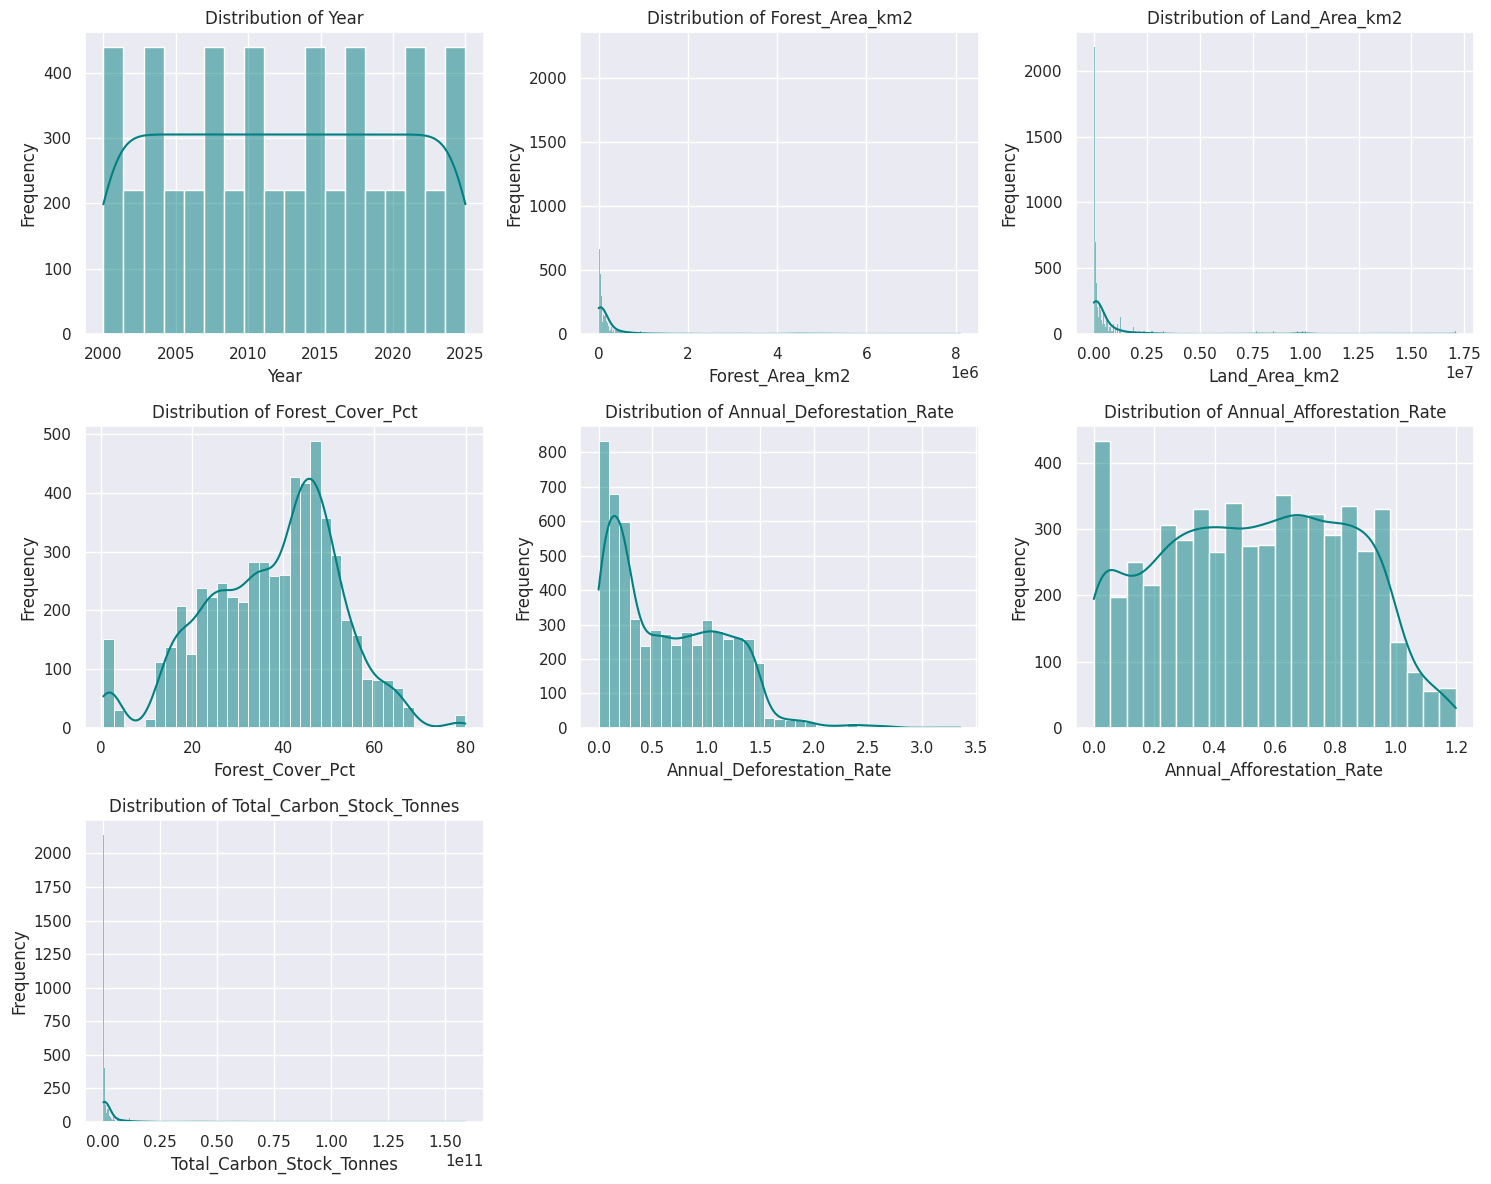

No categorical columns found (or all have high cardinality).


In [22]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

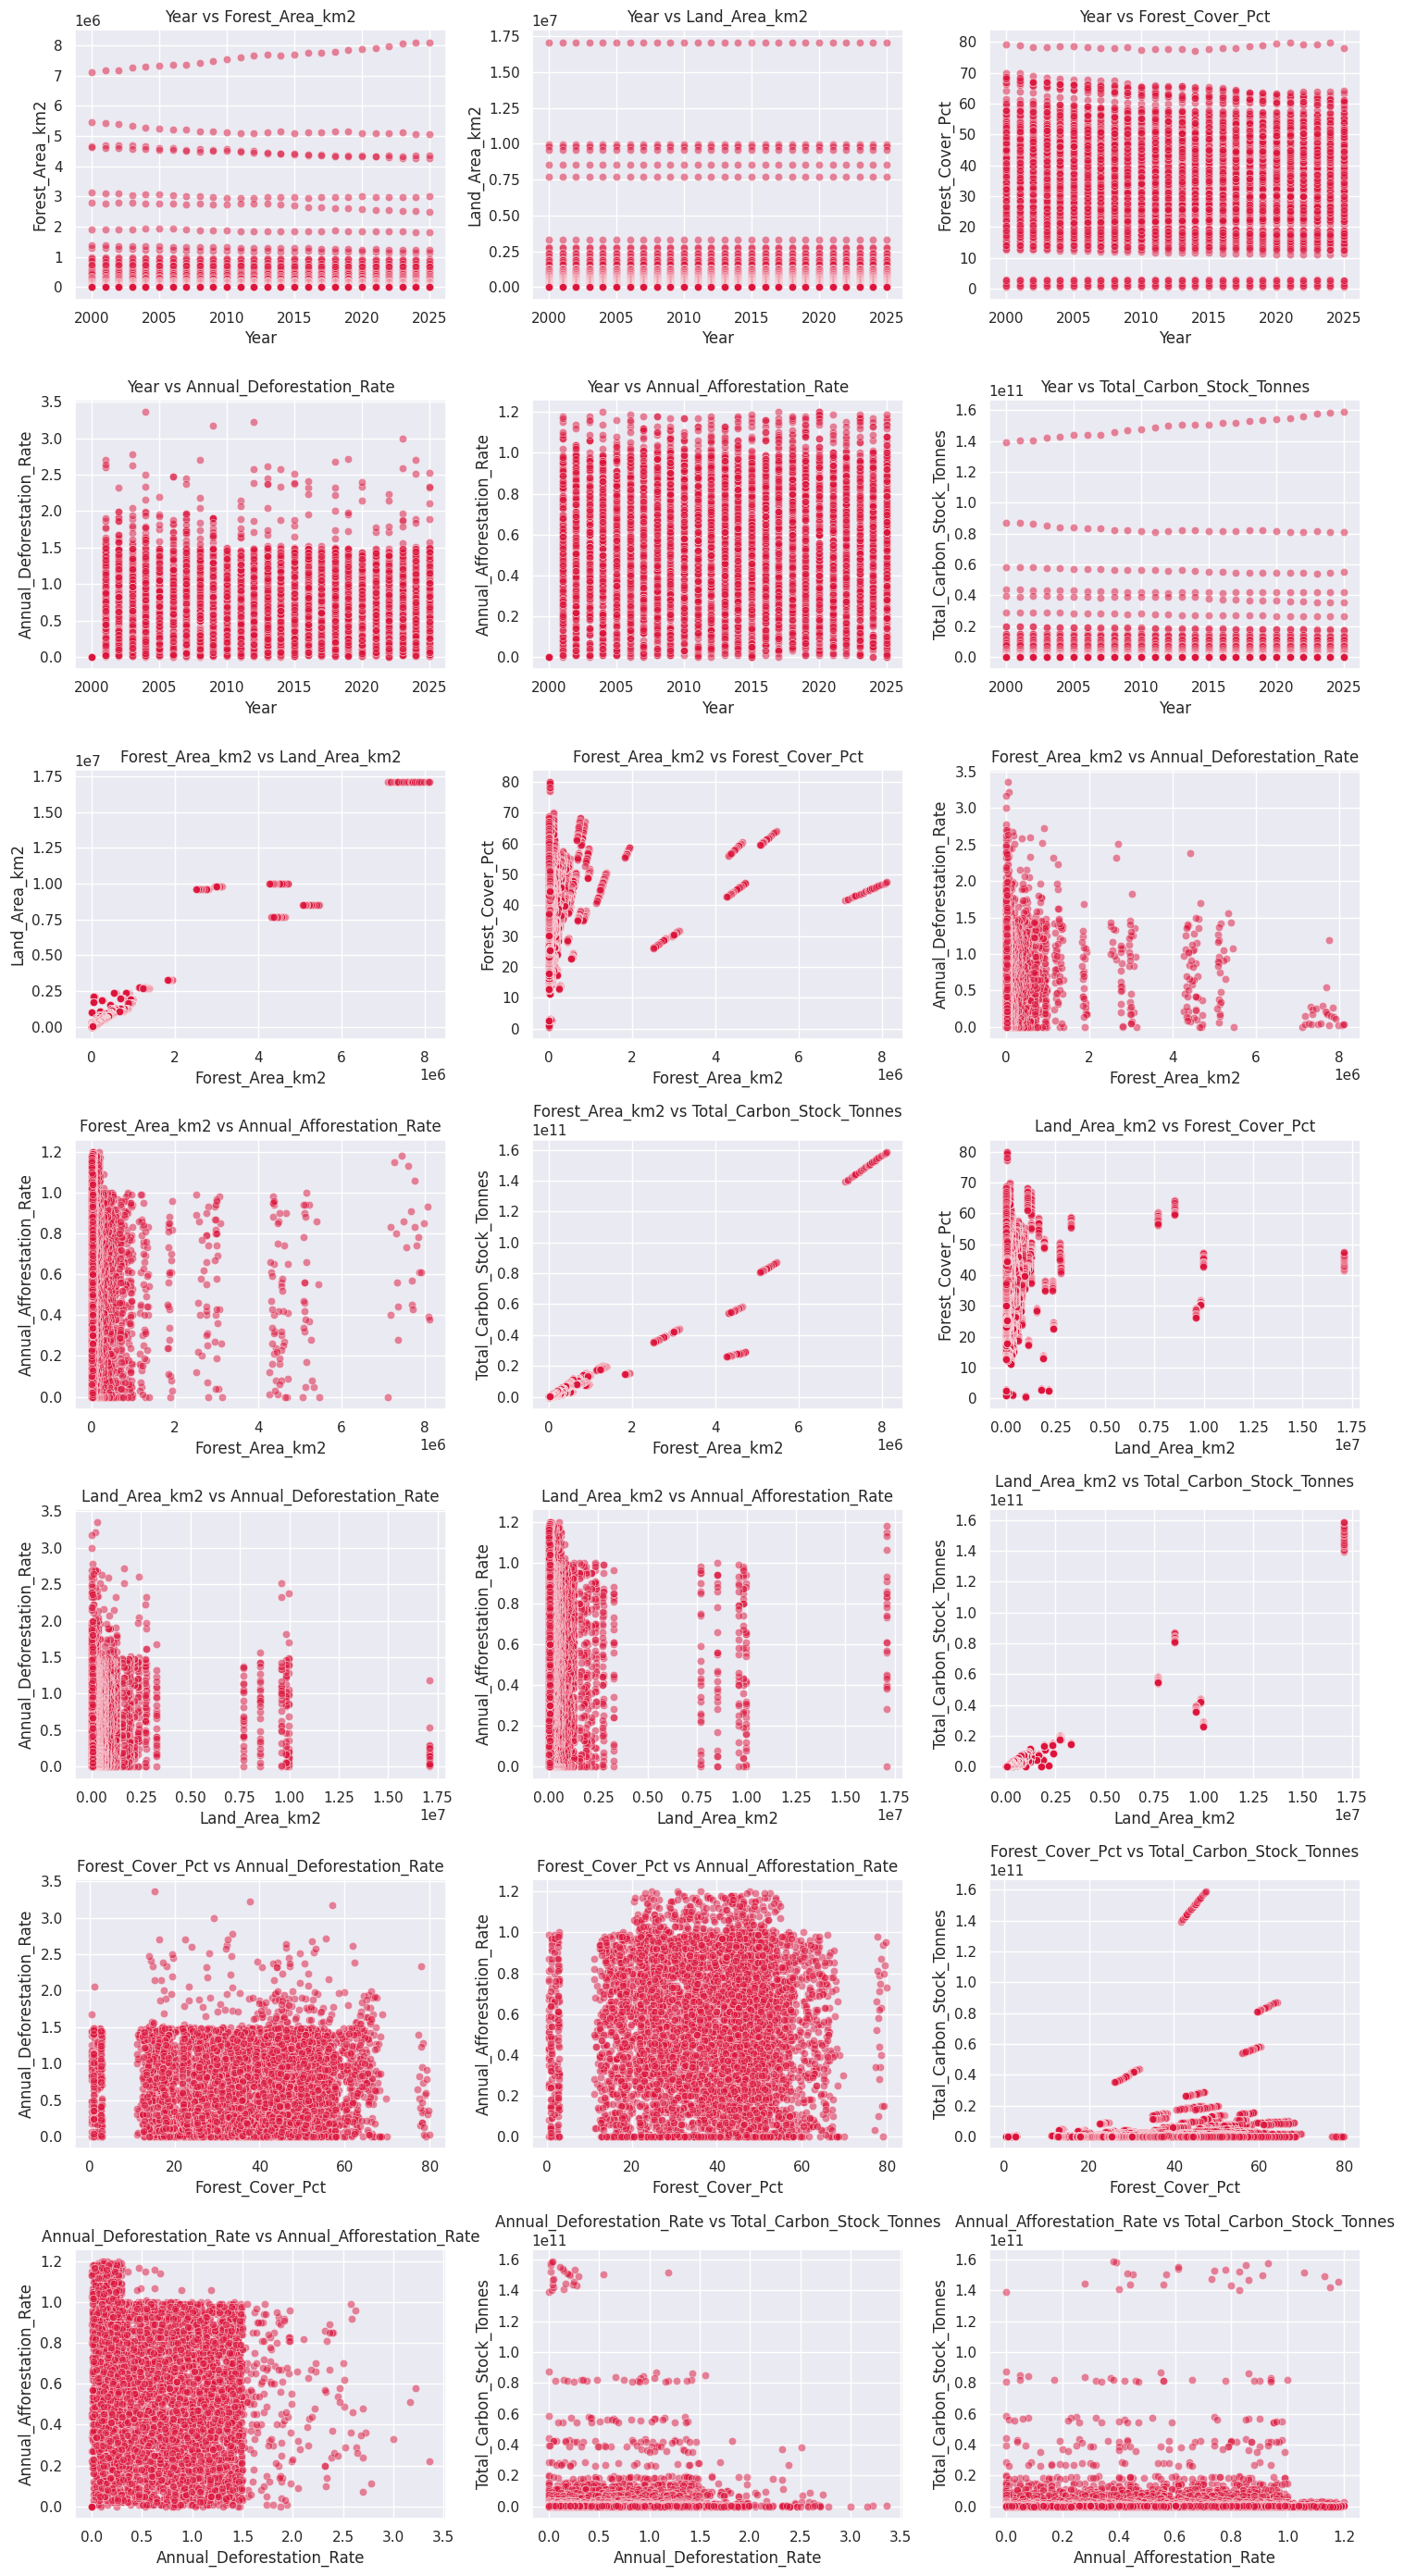

No categorical-numerical pairs found.


In [23]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Pairplot

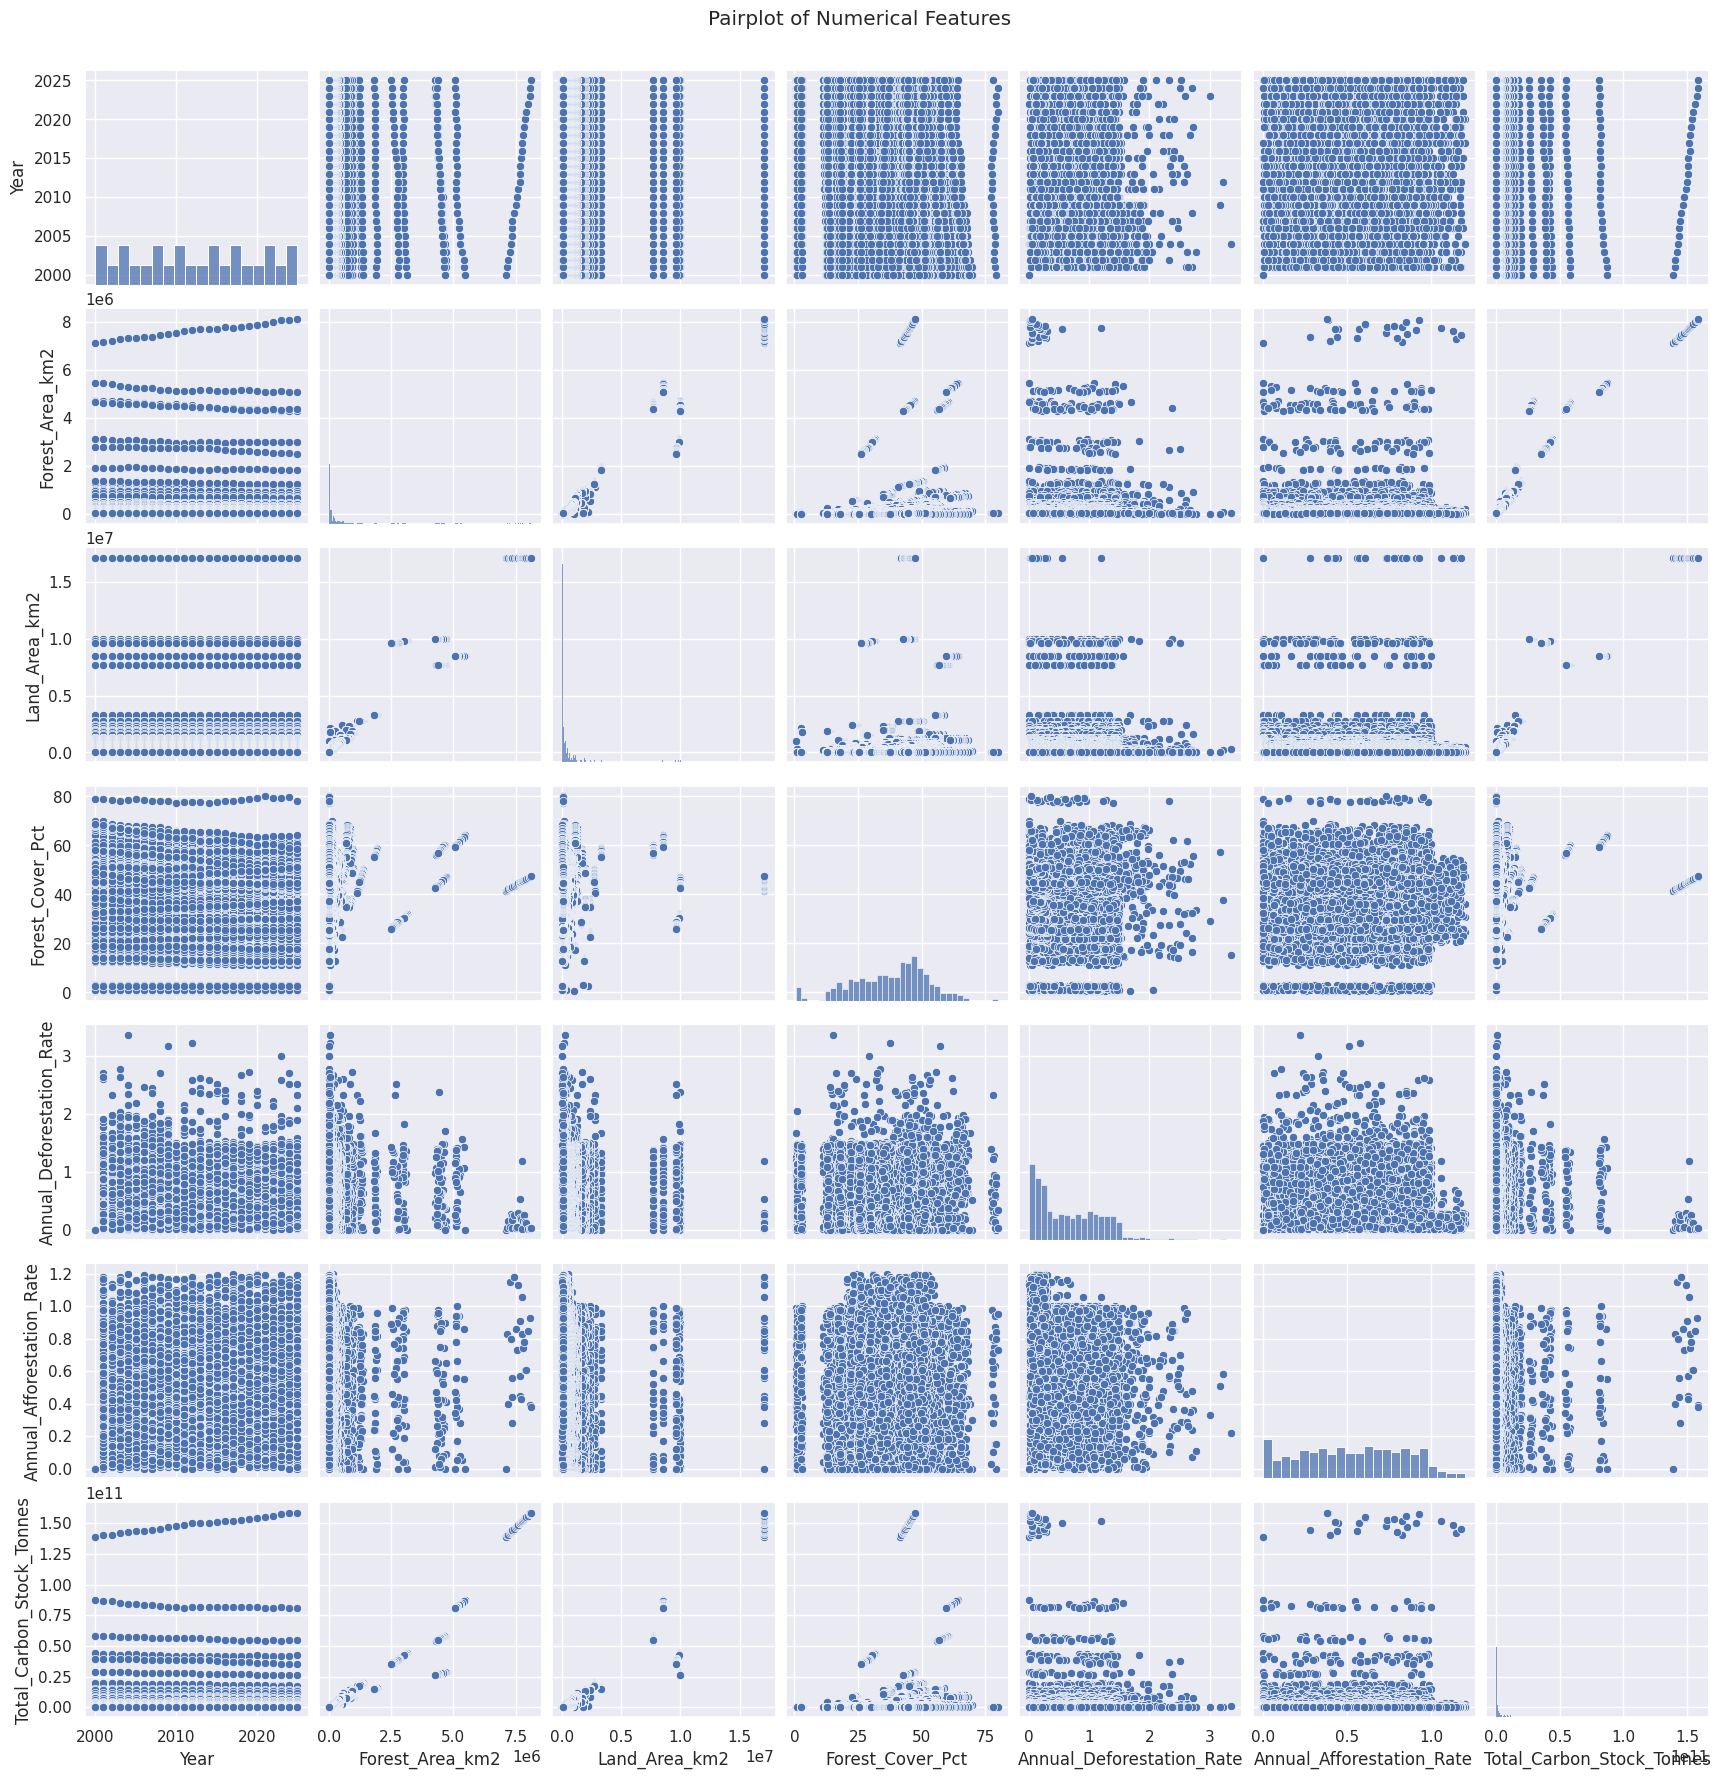

In [25]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

# Heatmap

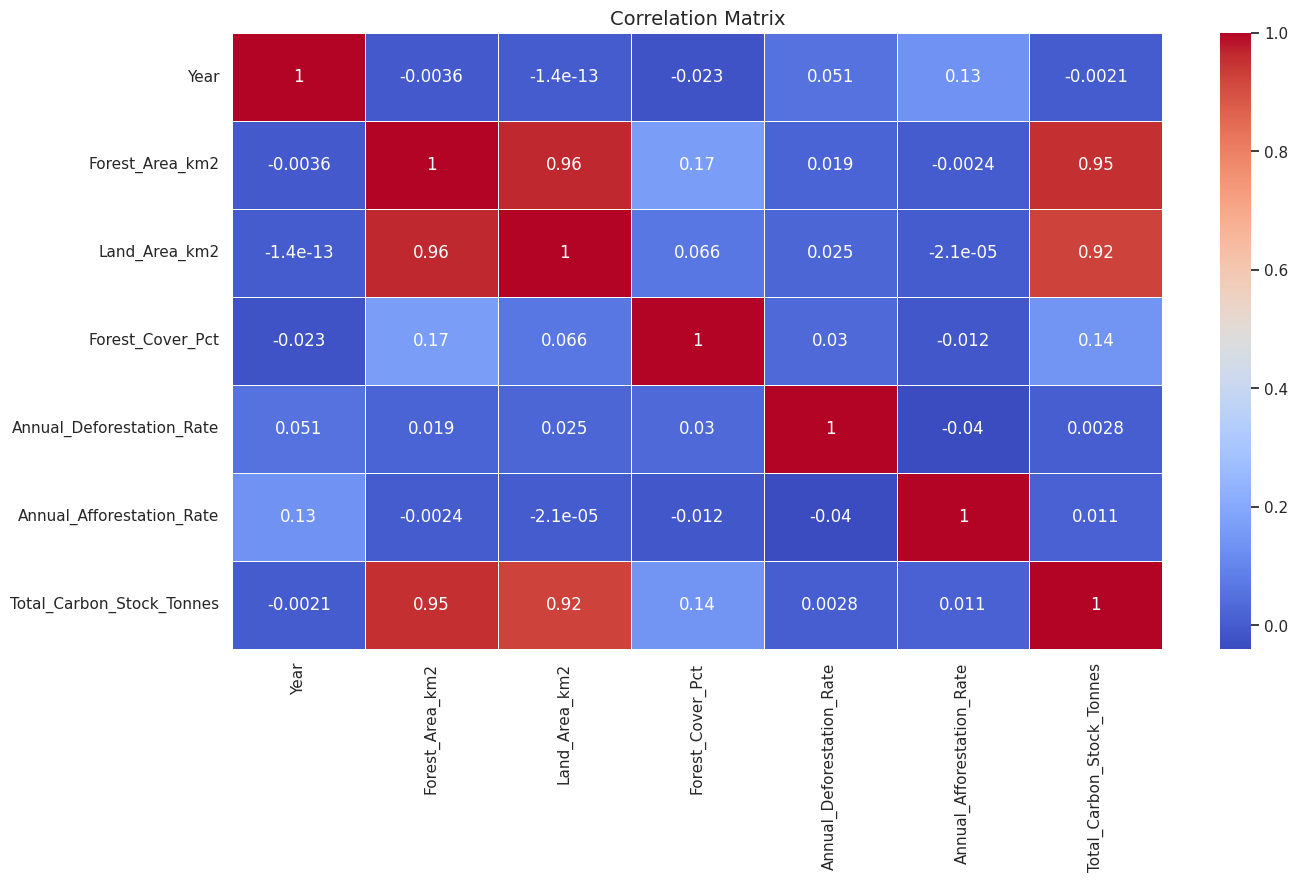

In [26]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

--- 1. ENGINEERING NET-ECOLOGICAL METRICS ---
Engineered: 'Net_Forest_Change_Rate' and 'Carbon_Density_Per_km2' to quantify ecological health.

--- 2. THE NET-ZERO TRAJECTORY (WILCOXON SIGNED-RANK TEST) ---
Average Annual Deforestation Rate: 0.6427
Average Annual Afforestation Rate: 0.5307
Wilcoxon P-Value (Net-Zero Variance): 1.3840e-29
 Insight: Statistically significant Ecological Decline. Global afforestation efforts are mathematically failing to offset deforestation.


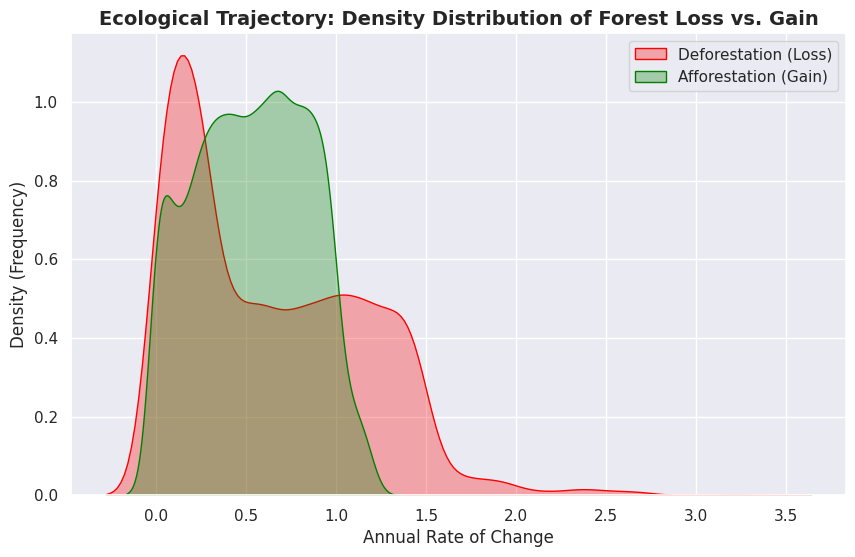


--- 3. THE ECOLOGICAL DRIVER IMPACT (KRUSKAL-WALLIS H-TEST) ---

--- 4. THE CARBON DEGRADATION PARADOX (SPEARMAN RANK CORRELATION) ---
Spearman Correlation Coefficient (Net Change vs. Carbon Density): -0.1054
P-Value: 1.3026e-15
Insight: Negative correlation detected. Smaller forests are becoming denser and holding more carbon per km2.


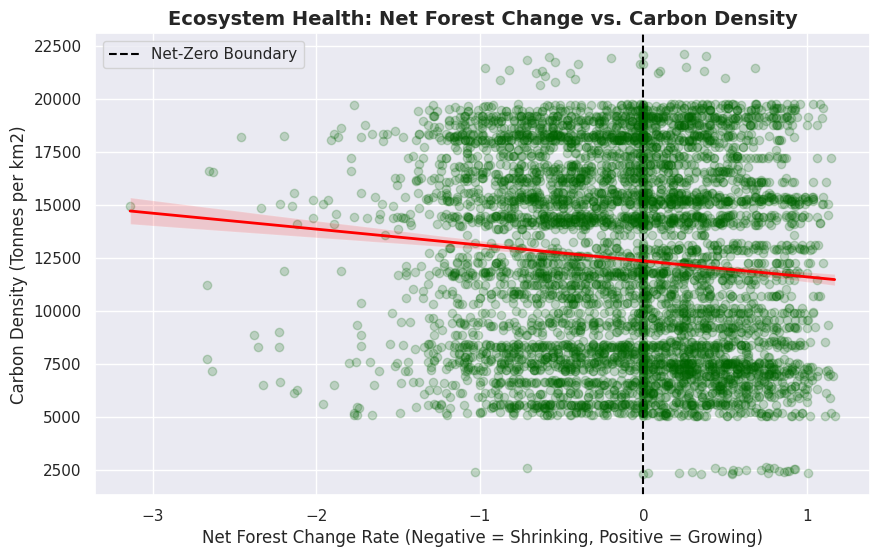

In [28]:
import scipy.stats as stats

print("--- 1. ENGINEERING NET-ECOLOGICAL METRICS ---")
if 'Primary_Driver_of_Change' not in df.columns:
    print("Warning: You dropped 'Primary_Driver_of_Change' earlier in the notebook. Please remove that drop() command!")
else:
    df['Primary_Driver_of_Change'] = df['Primary_Driver_of_Change'].fillna('Unknown')

df_clean = df.dropna(subset=['Annual_Deforestation_Rate', 'Annual_Afforestation_Rate', 'Total_Carbon_Stock_Tonnes']).copy()

# Calculating Net Forest Change Rate (Positive = Growing Forest, Negative = Shrinking Forest)
df_clean['Net_Forest_Change_Rate'] = df_clean['Annual_Afforestation_Rate'] - df_clean['Annual_Deforestation_Rate']

# Calculating Carbon Density (Tonnes of Carbon per km2 of Forest) to measure ecosystem health
# A high area with low density means degraded, unhealthy forests.
df_clean['Carbon_Density_Per_km2'] = df_clean['Total_Carbon_Stock_Tonnes'] / df_clean['Forest_Area_km2'].replace(0, 1)

print("Engineered: 'Net_Forest_Change_Rate' and 'Carbon_Density_Per_km2' to quantify ecological health.")


# :::::: CLIMATE HYPOTHESIS TESTING ::::::

print("\n--- 2. THE NET-ZERO TRAJECTORY (WILCOXON SIGNED-RANK TEST) ---")
# Is global Afforestation keeping up with Deforestation?
# Because these are paired observations for the exact same country/year, and distributions are skewed, we use Wilcoxon.

stat, p_val_wilcoxon = stats.wilcoxon(df_clean['Annual_Afforestation_Rate'], df_clean['Annual_Deforestation_Rate'])

print(f"Average Annual Deforestation Rate: {df_clean['Annual_Deforestation_Rate'].mean():.4f}")
print(f"Average Annual Afforestation Rate: {df_clean['Annual_Afforestation_Rate'].mean():.4f}")
print(f"Wilcoxon P-Value (Net-Zero Variance): {p_val_wilcoxon:.4e}")

if p_val_wilcoxon < 0.05:
    if df_clean['Annual_Deforestation_Rate'].mean() > df_clean['Annual_Afforestation_Rate'].mean():
        print(" Insight: Statistically significant Ecological Decline. Global afforestation efforts are mathematically failing to offset deforestation.")
    else:
        print(" Insight: Statistically significant Ecological Recovery. Afforestation is mathematically outpacing deforestation.")
else:
    print(" Insight: Null Hypothesis accepted. We are in a state of Net-Zero equilibrium.")

# Visualizing the Trajectory
plt.figure(figsize=(10, 6))
sns.kdeplot(df_clean['Annual_Deforestation_Rate'], label='Deforestation (Loss)', color='red', fill=True, alpha=0.3)
sns.kdeplot(df_clean['Annual_Afforestation_Rate'], label='Afforestation (Gain)', color='green', fill=True, alpha=0.3)
plt.title('Ecological Trajectory: Density Distribution of Forest Loss vs. Gain', fontsize=14, fontweight='bold')
plt.xlabel('Annual Rate of Change')
plt.ylabel('Density (Frequency)')
plt.legend()
plt.show()


print("\n--- 3. THE ECOLOGICAL DRIVER IMPACT (KRUSKAL-WALLIS H-TEST) ---")
# Does the *reason* for deforestation (the Primary Driver) mathematically dictate the *severity* of the destruction?
# We use Kruskal-Wallis because deforestation rates violate strict normal Gaussian distributions.

if 'Primary_Driver_of_Change' in df_clean.columns:
    # Isolating top known drivers
    valid_drivers = df_clean[df_clean['Primary_Driver_of_Change'] != 'Unknown']
    top_drivers = valid_drivers['Primary_Driver_of_Change'].value_counts().head(4).index.tolist()

    driver_groups = [valid_drivers[valid_drivers['Primary_Driver_of_Change'] == driver]['Annual_Deforestation_Rate'] for driver in top_drivers]

    if len(driver_groups) > 1:
        h_stat, p_val_kw = stats.kruskal(*driver_groups)

        print(f"Kruskal-Wallis P-Value (Driver Variance): {p_val_kw:.4e}")
        if p_val_kw < 0.05:
            print("Insight: The variance in destruction severity across different drivers is statistically significant.")
            print("-> Causal Mapping: Certain economic activities (e.g., Commercial Agriculture vs. Urbanization) induce fundamentally worse mathematical baseline destruction.")
        else:
            print("Insight: The specific driver does not matter. All ecological threats destroy forests at the same statistical rate.")

        # Visualizing the Driver Impact
        plt.figure(figsize=(12, 6))
        sns.boxplot(x='Primary_Driver_of_Change', y='Annual_Deforestation_Rate', data=valid_drivers[valid_drivers['Primary_Driver_of_Change'].isin(top_drivers)], order=top_drivers, palette='YlOrRd')
        plt.title('Causal Destruction: Deforestation Severity by Primary Driver', fontsize=14, fontweight='bold')
        plt.xlabel('Primary Driver of Ecological Change')
        plt.ylabel('Annual Deforestation Rate')
        plt.show()


print("\n--- 4. THE CARBON DEGRADATION PARADOX (SPEARMAN RANK CORRELATION) ---")
# As the Net Forest Change Rate goes negative (shrinking forests), does the overall ecosystem Carbon Density collapse?
# We use Spearman's Rank to test the monotonic relationship between forest shrinkage and carbon sink failure.

spearman_coef, p_val_spearman = stats.spearmanr(df_clean['Net_Forest_Change_Rate'], df_clean['Carbon_Density_Per_km2'])

print(f"Spearman Correlation Coefficient (Net Change vs. Carbon Density): {spearman_coef:.4f}")
print(f"P-Value: {p_val_spearman:.4e}")

if p_val_spearman < 0.05:
    if spearman_coef > 0:
        print("Insight: Positive correlation detected. As net forest growth decreases (deforestation wins), the actual biological quality and Carbon Density of the remaining forest mathematically collapses.")
    else:
        print("Insight: Negative correlation detected. Smaller forests are becoming denser and holding more carbon per km2.")
else:
    print("Insight: Null Hypothesis accepted. Net forest change has no mathematical relationship with the carbon density of the ecosystem.")

# Visualizing Carbon Degradation
plt.figure(figsize=(10, 6))
sns.regplot(x='Net_Forest_Change_Rate', y='Carbon_Density_Per_km2', data=df_clean,
            scatter_kws={'alpha':0.2, 'color':'darkgreen'}, line_kws={'color':'red', 'linewidth':2})
plt.axvline(0, color='black', linestyle='--', label='Net-Zero Boundary')
plt.title('Ecosystem Health: Net Forest Change vs. Carbon Density', fontsize=14, fontweight='bold')
plt.xlabel('Net Forest Change Rate (Negative = Shrinking, Positive = Growing)')
plt.ylabel('Carbon Density (Tonnes per km2)')
plt.legend()
plt.show()

## Advanced Statistical Analysis

--- 1. TIME-SERIES PREPARATION & GLOBAL AGGREGATION ---
Time-Series Index successfully established: 2000 to 2025.

--- 2. AUTOREGRESSIVE FORECASTING (ARIMA) ---
ARIMA FORECAST (2026 - 2030):
2026-01-01    0.643110
2027-01-01    0.642058
2028-01-01    0.642013
2029-01-01    0.642011
2030-01-01    0.642010
Freq: YS-JAN

--- 3. ECOLOGICAL MOMENTUM FORECASTING (EXPONENTIAL SMOOTHING) ---
Exponential Smoothing Model successfully converged.

--- 4. VISUALIZING THE DECADE FORECAST (THE 2035 HORIZON) ---


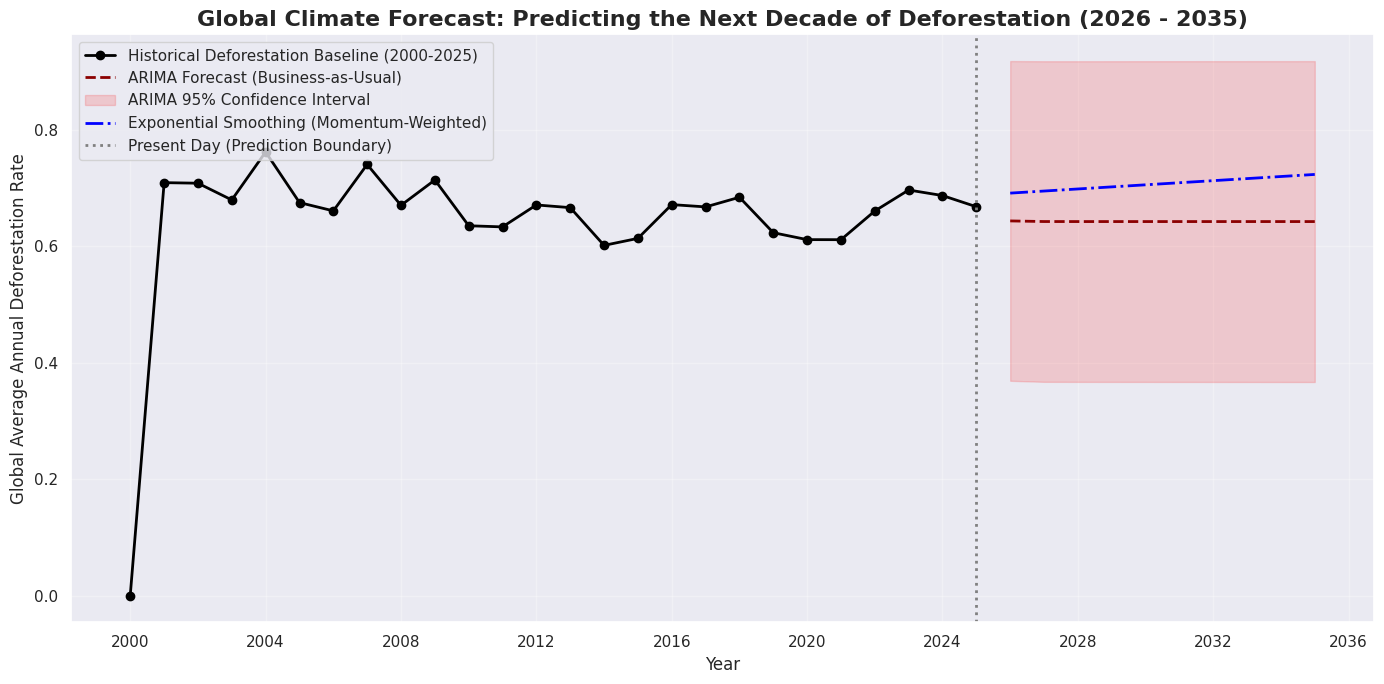


 FORECAST CONCLUSION:
   -> HOPEFUL: The algorithmic trajectory projects a 3.81% DECREASE in the deforestation rate by 2035.


In [35]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing


print("--- 1. TIME-SERIES PREPARATION & GLOBAL AGGREGATION ---")
# To run strict time-series math, we need a continuous, evenly spaced dataset.
# We will aggregate the global average Deforestation Rate per year.

ts_df = df_clean.groupby('Year')['Annual_Deforestation_Rate'].mean().reset_index()

# Convert Year to a strict Datetime Index (Required for advanced Time-Series)
ts_df['Year'] = pd.to_datetime(ts_df['Year'], format='%Y')
ts_df.set_index('Year', inplace=True)
# Ensure the frequency is set to Annual ('AS' = Year Start)
ts_df = ts_df.asfreq('YS')

print(f"Time-Series Index successfully established: {ts_df.index.min().year} to {ts_df.index.max().year}.")


print("\n--- 2. AUTOREGRESSIVE FORECASTING (ARIMA) ---")
# We are predicting the "Business-as-Usual" (BAU) scenario for the next 10 years.
# We deploy an ARIMA(1, 1, 1) model: 1 AutoRegressive lag, 1 order of Integration (differencing), 1 Moving Average lag.

# Fitting the ARIMA Model
arima_model = ARIMA(ts_df['Annual_Deforestation_Rate'], order=(1, 1, 1))
arima_result = arima_model.fit()

# Forecast the next 10 years (2026 - 2035)
forecast_steps = 10
arima_forecast = arima_result.get_forecast(steps=forecast_steps)
arima_pred = arima_forecast.predicted_mean
arima_conf_int = arima_forecast.conf_int(alpha=0.05) # 95% Confidence Interval

print("ARIMA FORECAST (2026 - 2030):")
print(arima_pred.head(5).to_string())


print("\n--- 3. ECOLOGICAL MOMENTUM FORECASTING (EXPONENTIAL SMOOTHING) ---")
# Recent policy failures (or successes) matter more than data from the year 2000.
# Holt's Linear Trend model assigns heavier mathematical weights to recent years.

# Fitting the Exponential Smoothing Model
es_model = ExponentialSmoothing(ts_df['Annual_Deforestation_Rate'], trend='add', seasonal=None, initialization_method="estimated")
es_result = es_model.fit()

# Forecast the next 10 years
es_pred = es_result.forecast(steps=forecast_steps)

print("Exponential Smoothing Model successfully converged.")


print("\n--- 4. VISUALIZING THE DECADE FORECAST (THE 2035 HORIZON) ---")
# We will plot the historical ecological baseline against both the ARIMA and Exponential forecasts.

plt.figure(figsize=(14, 7))

# Plotting Historical Data
plt.plot(ts_df.index, ts_df['Annual_Deforestation_Rate'], color='black', marker='o', linewidth=2, label='Historical Deforestation Baseline (2000-2025)')

# Plotting ARIMA Forecast
plt.plot(arima_pred.index, arima_pred, color='darkred', linestyle='--', linewidth=2, label='ARIMA Forecast (Business-as-Usual)')
# Shading the ARIMA 95% Confidence Interval
plt.fill_between(arima_conf_int.index,
                 arima_conf_int.iloc[:, 0],
                 arima_conf_int.iloc[:, 1],
                 color='red', alpha=0.15, label='ARIMA 95% Confidence Interval')

# Plotting Exponential Smoothing Forecast
plt.plot(es_pred.index, es_pred, color='blue', linestyle='-.', linewidth=2, label='Exponential Smoothing (Momentum-Weighted)')

plt.title('Global Climate Forecast: Predicting the Next Decade of Deforestation (2026 - 2035)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Global Average Annual Deforestation Rate', fontsize=12)
plt.axvline(ts_df.index[-1], color='gray', linestyle=':', linewidth=2, label='Present Day (Prediction Boundary)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n FORECAST CONCLUSION:")
# Calculating the total mathematical shift
baseline_current = ts_df['Annual_Deforestation_Rate'].iloc[-1]
forecast_2035 = arima_pred.iloc[-1]
pct_change = ((forecast_2035 - baseline_current) / baseline_current) * 100

if pct_change > 0:
    print(f"   -> WARNING: Under the current geopolitical trajectory, the global deforestation rate is projected to INCREASE by {pct_change:.2f}% by 2035.")
else:
    print(f"   -> HOPEFUL: The algorithmic trajectory projects a {abs(pct_change):.2f}% DECREASE in the deforestation rate by 2035.")

# Feature Engineering

In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

print("--- 1. TARGET ISOLATION & DATA SANITIZATION ---")
# We predict the 'Annual_Deforestation_Rate'.
# Notice we completely removed 'Primary_Driver_of_Change' from the required subset.
ml_df = df_clean.dropna(subset=['Annual_Deforestation_Rate', 'Country', 'Forest_Cover_Pct', 'Land_Area_km2']).copy()
y = ml_df['Annual_Deforestation_Rate']

print(" Target Formulated: 'Annual_Deforestation_Rate' isolated.")


print("\n--- 2. SOVEREIGN RISK MAPPING (BAYESIAN TARGET ENCODING) ---")
# Algorithms cannot read "Brazil" or "Canada". We replace the country's name with its
# historical average deforestation rate, smoothed to prevent overfitting on small nations.

global_mean_deforestation = ml_df['Annual_Deforestation_Rate'].mean()
smoothing_weight = 5

def smoothed_target_encode(df, category_col, target_col, weight, global_mean):
    agg = df.groupby(category_col)[target_col].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    smoothed_means = (counts * means + weight * global_mean) / (counts + weight)
    return df[category_col].map(smoothed_means)

ml_df['Sovereign_Risk_Encoded'] = smoothed_target_encode(ml_df, 'Country', 'Annual_Deforestation_Rate', smoothing_weight, global_mean_deforestation)

print(" Engineered: High-cardinality 'Country' vectors compressed into a Bayesian Sovereign Risk score.")


print("\n--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---")
# Gradient algorithms are highly sensitive to massive numbers. We must scale Land Area down
# so it doesn't mathematically overpower smaller percentage metrics.

continuous_features = ['Forest_Area_km2', 'Land_Area_km2', 'Forest_Cover_Pct', 'Annual_Afforestation_Rate', 'Carbon_Density_Per_km2', 'Sovereign_Risk_Encoded']

# Initialize the Standard Scaler
scaler = StandardScaler()
ml_df[continuous_features] = scaler.fit_transform(ml_df[continuous_features])

# Define the final Matrix (X), dropping the target, raw text, and redundant engineered columns
drop_cols = ['Country', 'Annual_Deforestation_Rate', 'Net_Forest_Change_Rate', 'Total_Carbon_Stock_Tonnes', 'Primary_Driver_of_Change']
X_adv = ml_df.drop(columns=drop_cols, errors='ignore').copy()

print(f" Final Machine-Readable Matrix Assembled: {X_adv.shape[1]} predictive dimensions ready for ML.")
print("\n Final Matrix (X_adv) Preview:")
print(X_adv.head(3))

--- 1. TARGET ISOLATION & DATA SANITIZATION ---
 Target Formulated: 'Annual_Deforestation_Rate' isolated.

--- 2. SOVEREIGN RISK MAPPING (BAYESIAN TARGET ENCODING) ---
 Engineered: High-cardinality 'Country' vectors compressed into a Bayesian Sovereign Risk score.

--- 3. CONTINUOUS VARIANCE STANDARDIZATION ---
 Final Machine-Readable Matrix Assembled: 8 predictive dimensions ready for ML.

 Final Matrix (X_adv) Preview:
   Year  Forest_Area_km2  Land_Area_km2  Forest_Cover_Pct  \
0  2000         6.455955       4.363471          1.819863   
1  2001         6.420650       4.363471          1.797151   
2  2002         6.382304       4.363471          1.771686   

   Annual_Afforestation_Rate  Carbon_Density_Per_km2  Deforestation_Z_Score  \
0                  -1.717050                0.771424              -1.234765   
1                   0.062300                0.771424               0.820792   
2                   1.065206                0.771425               1.512382   

   Sovereign_

# Machine Learning

--- 1. OUT-OF-SAMPLE DATA SPLITTING ---
 Training Set: 4576 records
 Testing Set: 1144 records (Strictly Unseen)

--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---
 Both Tree-Based Regression Architectures successfully trained.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---
 Random Forest Performance:
   -> Mean Absolute Error (MAE): 0.0004 Deforestation Rate Points
   -> Root Mean Squared Error (RMSE): 0.0052
   -> R-Squared (R2): 0.9999
----------------------------------------
 XGBoost Performance:
   -> Mean Absolute Error (MAE): 0.0004 Deforestation Rate Points
   -> Root Mean Squared Error (RMSE): 0.0085
   -> R-Squared (R2): 0.9997

 The Random Forest mathematically outperformed the alternative in predictive accuracy.

--- 4. VISUALIZING PREDICTIVE ACCURACY ---


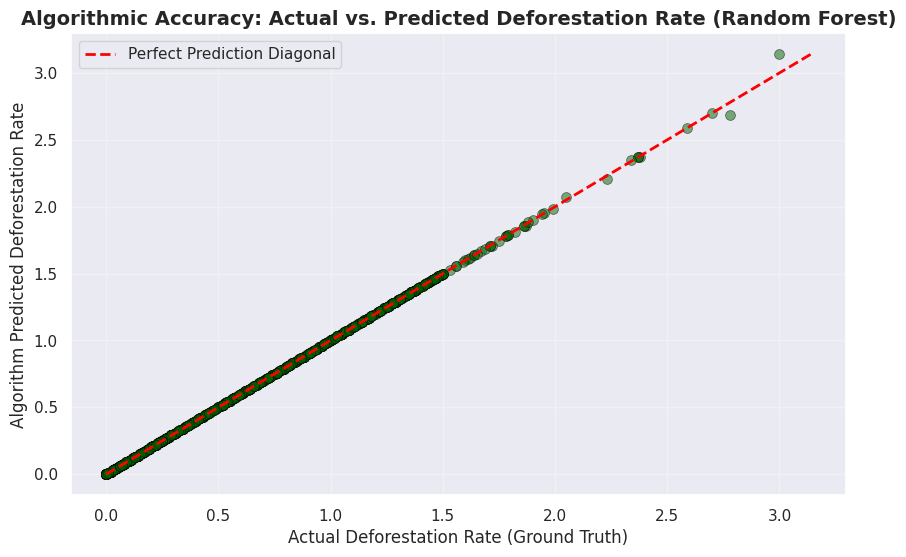


--- 5. ALGORITHMIC FEATURE IMPORTANCE ---


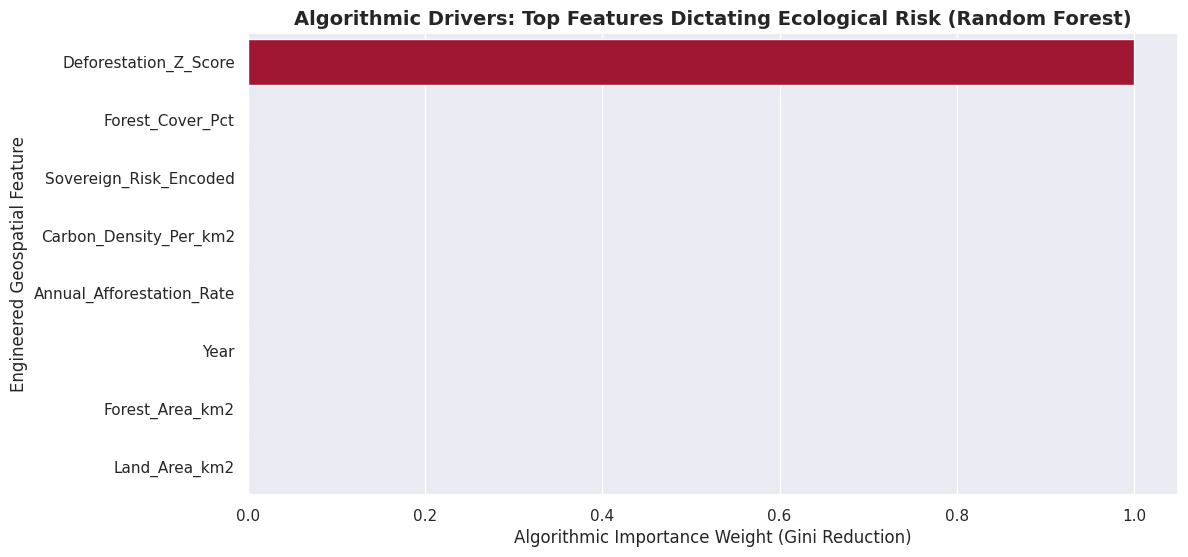

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("--- 1. OUT-OF-SAMPLE DATA SPLITTING ---")
# We split the data: 80% to train the algorithms, 20% to test their true accuracy out-of-sample.

X_train, X_test, y_train, y_test = train_test_split(X_adv, y, test_size=0.2, random_state=42)

print(f" Training Set: {len(X_train)} records")
print(f" Testing Set: {len(X_test)} records (Strictly Unseen)")


print("\n--- 2. ALGORITHMIC TRAINING (BAGGING VS. BOOSTING) ---")
# 1. Random Forest Regressor (Low-Variance Baseline)
rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost Regressor (High-Accuracy Boosting)
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" Both Tree-Based Regression Architectures successfully trained.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Force the models to predict the unseen 20%
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f" {name} Performance:")
    print(f"   -> Mean Absolute Error (MAE): {mae:.4f} Deforestation Rate Points")
    print(f"   -> Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"   -> R-Squared (R2): {r2:.4f}")
    return r2, mae

r2_rf, mae_rf = evaluate_model("Random Forest", y_test, rf_preds)
print("-" * 40)
r2_xgb, mae_xgb = evaluate_model("XGBoost", y_test, xgb_preds)

# Selecting the winner
best_model_name = "XGBoost" if r2_xgb > r2_rf else "Random Forest"
best_preds = xgb_preds if r2_xgb > r2_rf else rf_preds
best_model = xgb_model if r2_xgb > r2_rf else rf_model

print(f"\n The {best_model_name} mathematically outperformed the alternative in predictive accuracy.")



print("\n--- 4. VISUALIZING PREDICTIVE ACCURACY ---")
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.5, color='darkgreen', edgecolor='black', s=50)

# Lining of Perfect Prediction
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Diagonal')

plt.title(f'Algorithmic Accuracy: Actual vs. Predicted Deforestation Rate ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Deforestation Rate (Ground Truth)', fontsize=12)
plt.ylabel('Algorithm Predicted Deforestation Rate', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()



print("\n--- 5. ALGORITHMIC FEATURE IMPORTANCE ---")
importances = pd.Series(best_model.feature_importances_, index=X_adv.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=importances.values, y=importances.index, palette='YlOrRd_r')
plt.title(f'Algorithmic Drivers: Top Features Dictating Ecological Risk ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Geospatial Feature', fontsize=12)
plt.show()

# Thank You